## 1. Setup and Imports

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# METEOR Interface (new simplified API)
from meteor import MeteorInterface

print("✅ Imports complete")

✅ Imports complete


## 2. Initialize and Train Emulator

The `MeteorInterface` handles all the complexity:
- Data loading from CMIP6
- Pattern scaling model training
- Noise model training
- Variable-specific transforms (precipitation → Gamma distribution)

In [2]:
# Create emulator for both temperature and precipitation
emulator = MeteorInterface.from_cmip6(
    model='NorESM2-MM',
    variables=['tas', 'pr'],
    cache_dir='../cache'
)

print(f"Emulator created for: {emulator.variables}")
print(f"TAS transform: {emulator.transforms['tas'].transform_type}")
print(f"PR transform: {emulator.transforms['pr'].transform_type} ")

Emulator created for: ['tas', 'pr']
TAS transform: None
PR transform: gamma 


In [3]:
# Define regions and points
regions = ['NEU', 'NSA', 'EAS']
region_names = {
    'NEU': 'Northern Europe',
    'NSA': 'Northern South America',
    'EAS': 'East Asia'
}

cities = {
    'Oslo': {'lat': 59.9, 'lon': 10.8},
    'Delhi': {'lat': 28.6, 'lon': 77.2},
    #'Santiago': {'lat': -33.4, 'lon': 289.3},  # -70.7°W = 289.3°E
    'Cairo': {'lat': 30.0, 'lon': 31.2},
    'Beijing': {'lat': 39.9, 'lon': 116.4}
}

print(f"Regions: {', '.join(regions)}")
print(f"Cities: {', '.join(cities.keys())}")

Regions: NEU, NSA, EAS
Cities: Oslo, Delhi, Cairo, Beijing


In [4]:
# Train models (uses cached models if available)
emulator.train(auto=True, verbose=True)

Training METEOR emulator for NorESM2-MM
Variables: tas, pr

🔧 Training TAS...
   → Training pattern scaling model...
      ⚠️  Cache miss: Model name mismatch: expected 'cmip6-NorESM2-MM-aer', found 'cmip6-NorESM2-MM-aer-tas'
🔧 Preparing pattern scaling training data for NorESM2-MM...


   ✅ Training data prepared for experiments: ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 751 emission records
   ✅ Config: 1750-2100, emissions start: 1850
📦 Loading cached pattern scaling model from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
   → Training noise model...
Model loaded from ../cache/noise_models/NorESM2-MM_tas_noise_model.pkl
      ✓ Using cached noise model
   ✅ TAS training complete

🔧 Training PR...
   → Training pattern scaling model...
      ⚠️  Cache miss: Model name mismatch: expected 'cmip6-NorESM2-MM-aer', found 'cmip6-NorESM2-MM-aer-pr'
🔧 Preparing pattern scaling training data for NorESM2-MM...


   ✅ Training data prepared for experiments: ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 751 emission records
   ✅ Config: 1750-2100, emissions start: 1850
📦 Loading cached pattern scaling model from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-pr_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-pr_pattern_scaling.pkl
   → Training noise model...
Model loaded from ../cache/noise_models/NorESM2-MM_pr_noise_model.pkl
      ✓ Using cached noise model
   → Fitting gamma transform...
      Reason: Ensure positive-only values (precipitation cannot be negative)
   ✅ PR training complete

✅ All variables trained successfully


## 3. Define Locations

**Regions (AR6):**
- NEU: Northern Europe
- GIC: Greenland/Iceland
- NSA: Northern South America
- EAS: East Asia

**Cities:**
- Oslo: 59.9°N, 10.8°E
- Delhi: 28.6°N, 77.2°E
- Santiago: -33.4°S, -70.7°W (289.3°E)
- Beijing: 39.9°N, 116.4°E

## 4. Generate Ensemble

Generate 100 realizations with:
- Global mean
- 4 regional means
- 4 point locations
- Heating degree days for temperature

In [5]:
# Build aggregation list
timeseries = ['global']
timeseries += [f'regional:{r}' for r in regions]
timeseries += [f"point:{cities[c]['lat']},{cities[c]['lon']}" for c in cities.keys()]

print(f"Generating {len(timeseries)} spatial aggregations:")
for ts in timeseries:
    print(f"  - {ts}")

Generating 8 spatial aggregations:
  - global
  - regional:NEU
  - regional:NSA
  - regional:EAS
  - point:59.9,10.8
  - point:28.6,77.2
  - point:30.0,31.2
  - point:39.9,116.4


In [6]:
# Generate ensemble
ensemble = emulator.generate(
    scenario='ssp245',
    start_year=1850,
    end_year=2100,
    n_realizations=100,
    timeseries=timeseries,
    impacts={
        'tas': {
            'degree_days': {
                'hdd_base': 18.0,
                'cdd_base': 18.0
            }
        }
    },
    verbose=True
)

Generating ensemble for ssp245
  Years: 1850-2100
  Realizations: 100

📊 Generating TAS...
   → Time series: 8 aggregations
      → Computing pattern scaling for tas, ssp245...
11
12
113
114
115
22
141
123
142


      → Loading CMIP6 training data for ssp245...
      → Converting tas to anomalies from piControl baseline...
      → Generating 100 stochastic PC realizations...
      • global
      • regional:NEU
      • regional:NSA
      • regional:EAS
      • point:59.9,10.8
      • point:28.6,77.2
      • point:30.0,31.2
      • point:39.9,116.4
   → Computing impact metrics...
         • HDD for global
         • HDD for regional:NEU
         • HDD for regional:NSA
         • HDD for regional:EAS
         • HDD for point:59.9,10.8
         • HDD for point:28.6,77.2
         • HDD for point:30.0,31.2
         • HDD for point:39.9,116.4
         • CDD for global
         • CDD for regional:NEU
         • CDD for regional:NSA
         • CDD for regional:EAS
         • CDD for point:59.9,10.8
         • CDD for point:28.6,77.2
         • CDD for point:30.0,31.2


         • CDD for point:39.9,116.4
   ✅ TAS complete

📊 Generating PR...
   → Time series: 8 aggregations
      → Computing pattern scaling for pr, ssp245...
11
12
113
114
115
22
141
123
142
      → Loading CMIP6 training data for ssp245...
      → Generating 100 stochastic PC realizations...
      • global
      • regional:NEU
      • regional:NSA
      • regional:EAS
      • point:59.9,10.8
      • point:28.6,77.2
      • point:30.0,31.2
      • point:39.9,116.4
   ✅ PR complete

✅ Generation complete


In [7]:
# Reload the meteor_interface module to pick up recent changes
import importlib
import meteor.meteor_interface
importlib.reload(meteor.meteor_interface)
from meteor import MeteorInterface
print("✅ Module reloaded")

✅ Module reloaded


In [8]:
# Generate ensemble with custom EU NECP emissions
# The SCM will use ssp245 concentrations as baseline by default
# Note: This scenario runs 1750-2050, so we'll generate to 2050
ensemble_custom = emulator.generate(
    scenario={
        'emissions': 'notebooks/notebook_data/eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt',
        'name': 'EU_NECP_2024'
    },
    start_year=1850,
    end_year=2050,  # Match emissions data availability
    n_realizations=50,  # Fewer realizations for demo
    timeseries=['global', 'regional:NEU'],
    verbose=True
)

print(f"\n✅ Custom scenario ensemble generated!")
print(f"Scenario: {ensemble_custom.metadata['scenario']}")
print(f"Variables: {ensemble_custom.metadata['variables']}")

Generating ensemble for EU_NECP_2024
  Years: 1850-2050
  Realizations: 50

📊 Generating TAS...
   → Time series: 2 aggregations
      → Computing pattern scaling for tas, custom scenario 'EU_NECP_2024'...
      → Loaded emissions from eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt
      → Loaded concentrations from ssp245_conc_RCMIP.txt
      → Emissions data ends at 2050, extending to 2100 (holding final values)
11
12
113
114
115
22
141
123
142
      → Loading CMIP6 training data for ssp245...
      → Converting tas to anomalies from piControl baseline...
      → Generating 50 stochastic PC realizations...
      • global
      • regional:NEU


   ✅ TAS complete

📊 Generating PR...
   → Time series: 2 aggregations
      → Computing pattern scaling for pr, custom scenario 'EU_NECP_2024'...
      → Loaded emissions from eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt
      → Loaded concentrations from ssp245_conc_RCMIP.txt
      → Emissions data ends at 2050, extending to 2100 (holding final values)
11
12
113
114
115
22
141
123
142


      → Loading CMIP6 training data for ssp245...
      → Generating 50 stochastic PC realizations...
      • global
      • regional:NEU
   ✅ PR complete

✅ Generation complete

✅ Custom scenario ensemble generated!
Scenario: EU_NECP_2024
Variables: ['tas', 'pr']


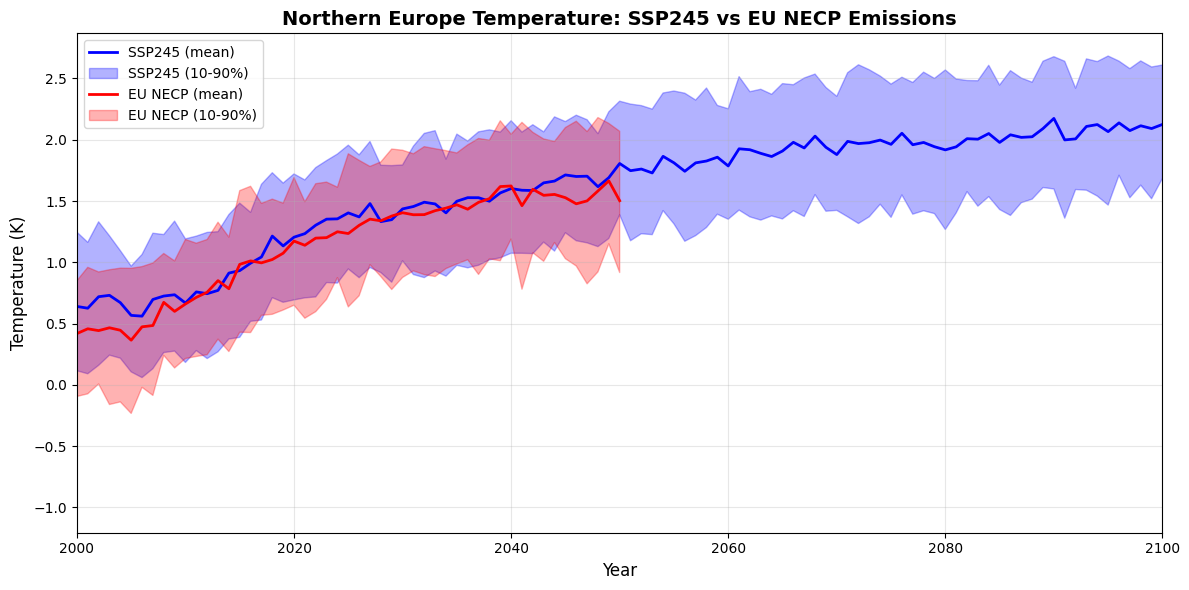

In [16]:
# Compare SSP245 vs EU NECP for Northern Europe temperature
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Extract NEU regional data
ssp245_neu = ensemble['tas'].timeseries['regional:NEU']
custom_neu = ensemble_custom['tas'].timeseries['regional:NEU']

# Resample to annual for cleaner plot
def resample_annual(data):
    """Resample monthly to annual means"""
    n_years = len(data) // 12
    return data[:n_years*12].reshape(n_years, 12).mean(axis=1)

# SSP245 (1850-2100)
ssp_annual = np.array([resample_annual(real) for real in ssp245_neu])
years_ssp_annual = np.arange(1850, 1850 + len(ssp_annual[0]))

ax.plot(years_ssp_annual, ssp_annual.mean(axis=0), 'b-', linewidth=2, label='SSP245 (mean)')
ax.fill_between(years_ssp_annual, 
                 np.percentile(ssp_annual, 10, axis=0),
                 np.percentile(ssp_annual, 90, axis=0),
                 alpha=0.3, color='blue', label='SSP245 (10-90%)')

# EU NECP (1850-2050)
custom_annual = np.array([resample_annual(real) for real in custom_neu])
years_custom_annual = np.arange(1850, 1850 + len(custom_annual[0]))

ax.plot(years_custom_annual, custom_annual.mean(axis=0), 'r-', linewidth=2, label='EU NECP (mean)')
ax.fill_between(years_custom_annual,
                 np.percentile(custom_annual, 10, axis=0),
                 np.percentile(custom_annual, 90, axis=0),
                 alpha=0.3, color='red', label='EU NECP (10-90%)')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.set_title('Northern Europe Temperature: SSP245 vs EU NECP Emissions', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(2000, 2100)

plt.tight_layout()
plt.show()


In [17]:
# List all available AR6 regions
from meteor import list_ar6_regions

list_ar6_regions()


AR6 IPCC Reference Regions:
  GIC    : Greenland/Iceland
  NWN    : N.W.North-America
  NEN    : N.E.North-America
  WNA    : W.North-America
  CNA    : C.North-America
  ENA    : E.North-America
  NCA    : N.Central-America
  SCA    : S.Central-America
  CAR    : Caribbean
  NWS    : N.W.South-America
  NSA    : N.South-America
  NES    : N.E.South-America
  SAM    : South-American-Monsoon
  SWS    : S.W.South-America
  SES    : S.E.South-America
  SSA    : S.South-America
  NEU    : N.Europe
  WCE    : West&Central-Europe
  EEU    : E.Europe
  MED    : Mediterranean
  SAH    : Sahara
  WAF    : Western-Africa
  CAF    : Central-Africa
  NEAF   : N.Eastern-Africa
  SEAF   : S.Eastern-Africa
  WSAF   : W.Southern-Africa
  ESAF   : E.Southern-Africa
  MDG    : Madagascar
  RAR    : Russian-Arctic
  WSB    : W.Siberia
  ESB    : E.Siberia
  RFE    : Russian-Far-East
  WCA    : W.C.Asia
  ECA    : E.C.Asia
  TIB    : Tibetan-Plateau
  EAS    : E.Asia
  ARP    : Arabian-Peninsula
  SAS    